# 04 — RUL Trajectories

Visualises the health-indicator degradation trajectories and the direct/health-indicator/combined RUL estimates computed by `src.evaluation.evaluate_rul` (committed results in `results/rul_ims/metrics.json`).


In [1]:
import sys
sys.path.insert(0, '..')

import json

import matplotlib.pyplot as plt
import pandas as pd

from src.data.ims_loader import load_ims_dataset


In [2]:
records = load_ims_dataset('../data/raw/ims/synthetic', source='synthetic')
df = pd.DataFrame([
    {'bearing_id': r.bearing_id, 'snapshot_index': r.snapshot_index,
     'rul_cycles': r.rul_cycles, 'health_indicator': r.health_indicator}
    for r in records
]).sort_values(['bearing_id', 'snapshot_index'])


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for bearing_id, g in df.groupby('bearing_id'):
    axes[0].plot(g['snapshot_index'], g['health_indicator'], marker='o', label=f'bearing {bearing_id}')
    axes[1].plot(g['snapshot_index'], g['rul_cycles'], marker='o', label=f'bearing {bearing_id}')
axes[0].set_title('Health indicator vs snapshot')
axes[1].set_title('True RUL (cycles) vs snapshot')
for ax in axes:
    ax.set_xlabel('snapshot index')
    ax.legend()
fig.tight_layout()


## Evaluated RUL metrics (bearing 1 fit -> bearing 2 test)

,rmse,mape,phm_score,n_samples
health_indicator_only,5.306242,8.666048e+01,4.985160,11.0
direct_regression_only,3.144628,3.729822e+07,3.017777,11.0
combined,3.144628,3.729822e+07,3.017777,11.0


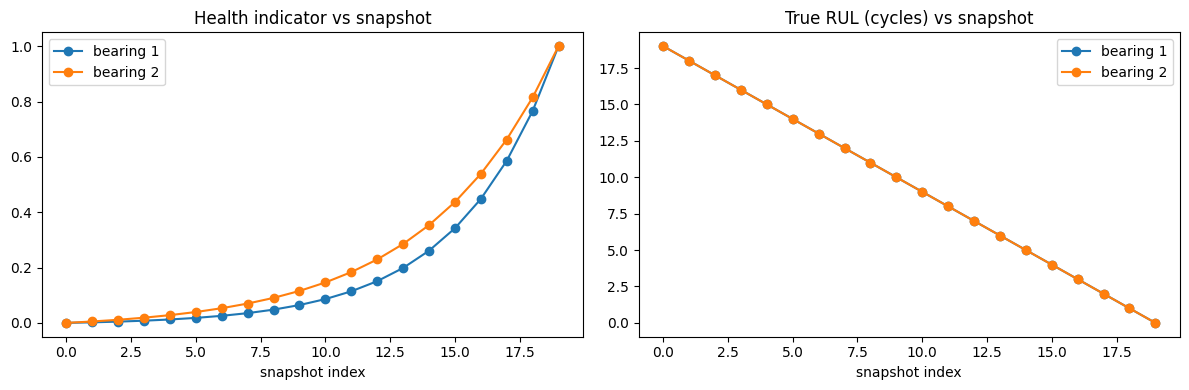

In [4]:
with open('../results/rul_ims/metrics.json') as f:
    rul_results = json.load(f)
pd.DataFrame({
    'health_indicator_only': rul_results['health_indicator_only'],
    'direct_regression_only': rul_results['direct_regression_only'],
    'combined': rul_results['combined'],
}).T
